In [1]:
from __future__ import annotations

import csv
import logging
import math
import sys
import time
import warnings
import optuna

from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import typer

from torch.amp import GradScaler, autocast
from torch.amp.autocast_mode import autocast
from torch.optim import Adam
from torch.utils.data import DataLoader as TorchDataLoader
from torch_geometric.data import Data, Dataset as PyGDataset
from torch_geometric.loader import DataLoader, DataLoader as PyGDataLoader
from tqdm import tqdm

from qqe.GNN.physics_aware_NN import QuantumCircuitGraphDataset
from qqe.experiments.plotting import plot_training_curves
from qqe.GNN.training.datasets import build_loaders, build_loaders_NN
from qqe.GNN.training.train import build_loss, train_model
from qqe.GNN.training.train_config import TrainConfig
from qqe.GNN.training.utils import (
    collect_files_path,
    evaluate_loss,
    unpack_supervised_batch,
)
from qqe.utils import configure_logger

logger = logging.getLogger(__name__)

_AMP_DEVICE_TYPE = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
from __future__ import annotations

import logging
from pathlib import Path

import numpy as np
import typer

from qqe.GNN.dataset_builder import DataGenConfig, run_dataset_pipeline
from qqe.utils import configure_logger

logger = logging.getLogger(__name__)

In [3]:
def collect_prediction_paths(dataset_root: str, family: str | None = None) -> list[str]:
    root = Path(dataset_root)
    pred_root = root / "predictions"

    if family is not None:
        paths = sorted((pred_root / family).glob("*.pt"))
    else:
        paths = []
        if pred_root.exists():
            for subdir in sorted(pred_root.iterdir()):
                if subdir.is_dir():
                    paths.extend(sorted(subdir.glob("*.pt")))

    return [str(p.resolve()) for p in paths]

In [31]:
backend = "pennylane"
training_target = "SRE"
method = "fwht"
use_dask = True
n_dask_workers = 4
dask_worker_memory_limit = "32GiB"
training_output_dir = f"data/training/{training_target}"
n_bins = 50
training_family = "haar,random,clifford,quansistor"
n_seeds_training = 150
qubit_range_training = np.arange(4, 10+1, 2)
layer_range = np.concatenate(([1], np.arange(2, 101, 2)))


In [16]:
print(layer_range)

[  1   2   4   6   8  10  12  14  16  18  20  22  24  26  28  30  32  34
  36  38  40  42  44  46  48  50  52  54  56  58  60  62  64  66  68  70
  72  74  76  78  80  82  84  86  88  90  92  94  96  98 100]


In [18]:
selected_families = [f.strip() for f in training_family.split(",") if f.strip()]

In [19]:
train_config = DataGenConfig(
    backend=backend,
    method=method,
    families=selected_families,
    qubits_values=qubit_range_training,
    layers_values=layer_range,
    n_seeds=n_seeds_training,
    n_bins=n_bins,
    compute_sre=training_target == "SRE",
    compute_EE=training_target == "EE",
    representation="dense",
    use_dask=use_dask,
    dask_n_workers=n_dask_workers,
    dask_memory_per_worker=dask_worker_memory_limit,
    output_dir=training_output_dir,
    max_configs=None,
)

In [20]:
print(train_config)

DataGenConfig(backend='pennylane', method='fwht', families=['haar', 'random', 'clifford', 'quansistor'], qubits_values=array([ 4,  6,  8, 10]), layers_values=array([  1,   2,   4,   6,   8,  10,  12,  14,  16,  18,  20,  22,  24,
        26,  28,  30,  32,  34,  36,  38,  40,  42,  44,  46,  48,  50,
        52,  54,  56,  58,  60,  62,  64,  66,  68,  70,  72,  74,  76,
        78,  80,  82,  84,  86,  88,  90,  92,  94,  96,  98, 100]), n_seeds=150, n_bins=50, compute_sre=True, compute_EE=False, representation='dense', use_dask=True, dask_n_workers=4, dask_memory_per_worker='32GiB', output_dir=WindowsPath('data/training/SRE'), max_configs=None)


In [10]:
run_dataset_pipeline(
    config=train_config,
    families=selected_families,
    qubits_values=qubit_range_training,
    layers_values=layer_range,
    n_seeds=n_seeds_training,
    use_dask=use_dask,
    max_configs=None,
    dask_n_workers=n_dask_workers,
    dask_memory_per_worker=dask_worker_memory_limit,
)

2026-05-07 12:25:41,840 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 32GiB due to system memory limit of 31.19 GiB
2026-05-07 12:25:41,854 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 32GiB due to system memory limit of 31.19 GiB
2026-05-07 12:25:41,870 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 32GiB due to system memory limit of 31.19 GiB
2026-05-07 12:25:41,886 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 32GiB due to system memory limit of 31.19 GiB
Parallel dataset generation: 100%|██████████| 30600/30600 [41:58<00:00, 12.15it/s]  
2026-05-07 13:07:43,657 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 32GiB due to system memory limit of 31.19 GiB
2026-05-07 13:07:43,672 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 32GiB due to system memory limit of 31.19 GiB
2026-05-07 13:07:43,687 - distributed.nanny.memory - WARNING - Ignoring pro

In [42]:
prediction_output_dir = "data/predictions"
prediction_family = "random"
n_seeds_prediction = 75
qubit_range_prediction = np.arange(12, 30+1, 2)

In [43]:
selected_families = [f.strip() for f in prediction_family.split(",") if f.strip()]
prediction_output_dir = Path(prediction_output_dir)

In [14]:
config = DataGenConfig(
    backend=backend,
    method=method,
    families=selected_families,
    qubits_values=qubit_range_prediction,
    layers_values=layer_range,
    n_seeds=n_seeds_prediction,
    n_bins=n_bins,
    compute_sre = False,
    compute_EE = False,
    representation="dense",
    use_dask=use_dask,
    dask_n_workers=n_dask_workers,
    dask_memory_per_worker=dask_worker_memory_limit,
    output_dir=prediction_output_dir,
    max_configs=None,
)

NameError: name 'backend' is not defined

In [45]:
run_dataset_pipeline(
    config=config,
    families=selected_families,
    qubits_values=qubit_range_prediction,
    layers_values=layer_range,
    n_seeds=n_seeds_prediction,
    use_dask=use_dask,
    max_configs=None,
    dask_n_workers=n_dask_workers,
    dask_memory_per_worker=dask_worker_memory_limit,
)

2026-05-07 17:32:56,653 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 32GiB due to system memory limit of 31.19 GiB
2026-05-07 17:32:56,667 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 32GiB due to system memory limit of 31.19 GiB
2026-05-07 17:32:56,683 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 32GiB due to system memory limit of 31.19 GiB
2026-05-07 17:32:56,698 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 32GiB due to system memory limit of 31.19 GiB
Parallel dataset generation: 100%|██████████| 38250/38250 [55:13<00:00, 11.54it/s]  


In [49]:
data_paths = collect_files_path(prediction_output_dir, family="random")
if not data_paths:
    raise RuntimeError("No data paths found.")
print(f"Found {len(data_paths)} data paths.")

Found 38250 data paths.


In [15]:
from torch.utils.data import DataLoader as TorchDataLoader, random_split
from torch_geometric.loader import DataLoader
from qqe.GNN.physics_aware_NN import QuantumCircuitGraphDataset
from qqe.GNN.training.utils import cache_root_paths, FamilyFeatureProjector, ProjectedDatasetWrapper
from qqe.GNN.training.datasets import PaddedGraphDatasetWrapper, GlobalTargetDatasetWrapper

@dataclass
class PreparedData:
    train_ds: object
    val_ds: object
    test_ds: object
    node_in_dim: int | None
    global_in_dim: int
    base_dataset: object
    loader_kind: str  # "gnn" or "nn"


def prepare_datasets(
    pt_paths: list[str],
    *,
    loader_kind: str,  # "gnn" | "nn"
    seed: int = 42,
    train_split: float = 0.8,
    val_split: float = 0.1,
    global_feature_variant: str = "binned",
    node_feature_variant: str | None = None,
    family_projection: str | None = None,
) -> PreparedData:
    suffix = (
        f"{global_feature_variant}"
        f"__backend_{node_feature_variant or 'none'}"
        f"_familyproj_{family_projection or 'none'}"
    )
    root = cache_root_paths(pt_paths, suffix=suffix)

    base_dataset = QuantumCircuitGraphDataset(
        root=root,
        pt_paths=pt_paths,
        global_feature_variant=global_feature_variant,
        node_feature_backend_variant=node_feature_variant,
    )

    if len(base_dataset) < 3:
        raise RuntimeError("Dataset too small for train/val/test splitting.")

    working_dataset = base_dataset

    if family_projection is not None:
        projector = FamilyFeatureProjector(
            family=family_projection,
            all_gate_keys=base_dataset.all_gate_keys,
        )
        working_dataset = ProjectedDatasetWrapper(
            working_dataset,
            transform=projector,
        )

    if loader_kind == "gnn":
        final_dataset = PaddedGraphDatasetWrapper(working_dataset)
        sample0 = final_dataset[0]
        node_in_dim = int(sample0.x.shape[1])
        global_in_dim = int(sample0.global_features.numel())

    elif loader_kind == "nn":
        final_dataset = GlobalTargetDatasetWrapper(working_dataset)
        sample0_g, _ = final_dataset[0]
        node_in_dim = None
        global_in_dim = int(sample0_g.numel())

    else:
        raise ValueError("loader_kind must be 'gnn' or 'nn'")

    generator = torch.Generator().manual_seed(seed)

    primary_train_len = max(1, int(len(final_dataset) * train_split))
    test_len = max(1, len(final_dataset) - primary_train_len)

    while primary_train_len + test_len > len(final_dataset):
        primary_train_len -= 1

    primary_train_dataset, test_ds = random_split(
        final_dataset,
        [primary_train_len, test_len],
        generator=generator,
    )

    val_len = max(1, int(len(primary_train_dataset) * val_split))
    real_train_len = max(1, len(primary_train_dataset) - val_len)

    train_ds, val_ds = random_split(
        primary_train_dataset,
        [real_train_len, val_len],
        generator=generator,
    )

    return PreparedData(
        train_ds=train_ds,
        val_ds=val_ds,
        test_ds=test_ds,
        node_in_dim=node_in_dim,
        global_in_dim=global_in_dim,
        base_dataset=base_dataset,
        loader_kind=loader_kind,
    )


def make_loaders(
    prepared: PreparedData,
    *,
    batch_size: int,
    num_workers: int = 0,
):
    pin_mem = torch.cuda.is_available()

    if prepared.loader_kind == "gnn":
        Loader = PyGDataLoader
    elif prepared.loader_kind == "nn":
        Loader = TorchDataLoader
    else:
        raise ValueError(f"Unknown loader_kind: {prepared.loader_kind}")

    return (
        Loader(
            prepared.train_ds,
            batch_size=batch_size,
            shuffle=True,
            num_workers=num_workers,
            pin_memory=pin_mem,
        ),
        Loader(
            prepared.val_ds,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            pin_memory=pin_mem,
        ),
        Loader(
            prepared.test_ds,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            pin_memory=pin_mem,
        ),
    )

def build_loaders(
    pt_paths: list[str],
    *,
    batch_size: int = 32,
    seed: int = 42,
    train_split: float = 0.8,
    val_split: float = 0.1,
    global_feature_variant: str = "binned",
    node_feature_variant: str | None = None,
    family_projection: str | None = None,
):
    prepared = prepare_datasets(
        pt_paths,
        loader_kind="gnn",
        seed=seed,
        train_split=train_split,
        val_split=val_split,
        global_feature_variant=global_feature_variant,
        node_feature_variant=node_feature_variant,
        family_projection=family_projection,
    )

    train_loader, val_loader, test_loader = make_loaders(
        prepared,
        batch_size=batch_size,
    )

    return (
        train_loader,
        val_loader,
        test_loader,
        prepared.node_in_dim,
        prepared.global_in_dim,
        prepared.base_dataset,
    )


def build_loaders_NN(
    pt_paths: list[str],
    *,
    batch_size: int = 32,
    seed: int = 42,
    train_split: float = 0.8,
    val_split: float = 0.1,
    global_feature_variant: str = "binned",
    node_feature_variant: str | None = None,
    family_projection: str | None = None,
):
    prepared = prepare_datasets(
        pt_paths,
        loader_kind="nn",
        seed=seed,
        train_split=train_split,
        val_split=val_split,
        global_feature_variant=global_feature_variant,
        node_feature_variant=node_feature_variant,
        family_projection=family_projection,
    )

    train_loader, val_loader, test_loader = make_loaders(
        prepared,
        batch_size=batch_size,
    )

    return (
        train_loader,
        val_loader,
        test_loader,
        prepared.global_in_dim,
        prepared.base_dataset,
    )

In [50]:
pt_paths = collect_prediction_paths(f"data/predictions/{target}_{method}", family)
if not pt_paths:
    raise RuntimeError("No prediction .pt files found.")

print(f"Found {len(pt_paths)} data paths.")

NameError: name 'target' is not defined

### Model definitions

In [16]:
GNN_HIDDEN = 32
GNN_HEADS = 2
GLOBAL_HIDDEN = 32
REG_HIDDEN = 32
NUM_LAYERS = 2
dropout_rate = 0.15


class GlobalMLP(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int = 64, dropout_rate: float = 0.0):
        super().__init__()
        dr = float(dropout_rate) if dropout_rate is not None else 0.0
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dr),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dr),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dr),
        )

    def forward(self, g: torch.Tensor) -> torch.Tensor:
        return self.net(g)


class Regressor(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int = 128, dropout_rate: float = 0.0):
        super().__init__()
        dr = float(dropout_rate) if dropout_rate is not None else 0.0
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dr),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dr),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, h: torch.Tensor) -> torch.Tensor:
        return self.net(h)

def _get_activation(activation: str) -> nn.Module:
    if activation == "relu":
        return nn.ReLU()
    elif activation == "elu":
        return nn.ELU()
    else:
        raise ValueError(f"Unsupported activation function: {activation}")


class NN(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int = 64, dropout_rate: float = 0.0):
        super().__init__()
        dr = float(dropout_rate) if dropout_rate is not None else 0.0
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dr),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dr),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dr),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, g: torch.Tensor) -> torch.Tensor:
        return self.net(g)

class GNN(nn.Module):
    def __init__(
        self,
        node_in_dim: int = 23,
        gnn_hidden: int = GNN_HIDDEN,
        gnn_heads: int = GNN_HEADS,
        global_in_dim: int = 8,
        global_hidden: int = GLOBAL_HIDDEN,
        reg_hidden: int = REG_HIDDEN,
        num_layers: int = NUM_LAYERS,
        dropout_rate: float = 0.1,
    ):
        super().__init__()
        from torch_geometric.nn import TransformerConv, global_mean_pool

        self.global_mean_pool = global_mean_pool

        if num_layers < 1:
            raise ValueError("num_layers must be >= 1")
        self.num_layers = int(num_layers)
        self.gnn_hidden = gnn_hidden
        self.gnn_heads = gnn_heads
        self.dropout_rate = float(dropout_rate) if dropout_rate is not None else 0.0

        conv_layers = [
            TransformerConv(
                node_in_dim, gnn_hidden, heads=gnn_heads, dropout=self.dropout_rate, beta=False
            ),
        ]
        conv_layers.extend(
            [
                TransformerConv(
                    gnn_hidden * gnn_heads,
                    gnn_hidden,
                    heads=gnn_heads,
                    dropout=self.dropout_rate,
                    beta=False,
                )
                for _ in range(1, self.num_layers)
            ],
        )
        self.conv_layers = nn.ModuleList(conv_layers)
        self.global_mlp = GlobalMLP(global_in_dim, global_hidden, dropout_rate=self.dropout_rate)
        concat_dim = gnn_hidden * gnn_heads + global_hidden
        self.regressor = Regressor(concat_dim, reg_hidden, dropout_rate=self.dropout_rate)


    def forward(self, data) -> torch.Tensor:
        x, edge_index = data.x, data.edge_index
        batch = getattr(data, "batch", None)
        if batch is None:
            batch = x.new_zeros(x.size(0), dtype=torch.long)
        num_graphs = int(batch.max().item() + 1) if batch.numel() else 1

        # GNN branch
        if x is None or x.size(0) == 0:
            x_pool = x.new_zeros((num_graphs, self.gnn_hidden * self.gnn_heads), dtype=torch.float32)
        else:
            with autocast(_AMP_DEVICE_TYPE, enabled=False):
                h = x.float()
                for conv in self.conv_layers:
                    h = F.relu(conv(h, edge_index))
                    if self.dropout_rate:
                        h = F.dropout(h, p=self.dropout_rate, training=self.training)
                x_pool = self.global_mean_pool(h, batch)

        # Global branch
        g = data.global_features
        if g.dim() == 1:
            if g.numel() % num_graphs != 0:
                raise RuntimeError(
                    f"Inconsistent global_features in batch: total={g.numel()}, "
                    f"num_graphs={num_graphs}. Expected fixed per-graph feature length."
                )
            g = g.view(num_graphs, -1)
        elif g.dim() == 2 and g.size(0) == num_graphs:
            pass
        else:
            g = g.reshape(num_graphs, -1)
        g_feat = self.global_mlp(g.float())

        # Combine
        out = self.regressor(torch.cat([x_pool, g_feat], dim=-1))
        return out.view(-1)

## Training helpers

In [17]:
def _resolve_model_save_path(base_path: str, allow_overwrite: bool = False) -> str:
    """Return a non-colliding checkpoint path unless overwrite is explicitly allowed."""
    path = Path(base_path)
    if allow_overwrite or not path.exists():
        return str(path)

    stem = path.stem
    suffix = path.suffix
    parent = path.parent
    counter = 1

    while True:
        candidate = parent / f"{stem}_v{counter}{suffix}"
        if not candidate.exists():
            print(
                "Model checkpoint already exists at %s. Saving to %s instead.",
                path,
                candidate,
            )
            return str(candidate)
        counter += 1

In [18]:
def _amp_device_type() -> str:
    return "cuda" if torch.cuda.is_available() else "cpu"

def build_loss(loss_type: str, huber_delta: float = 1.0) -> nn.Module:
    loss_type = loss_type.lower()
    if loss_type == "mse":
        return nn.MSELoss()
    if loss_type == "l1":
        return nn.L1Loss()
    if loss_type == "huber":
        return nn.HuberLoss(delta=huber_delta)
    raise ValueError(f"Unsupported loss type: {loss_type}")


@dataclass
class TrainHistory:
    train_loss: list[float]
    val_loss: list[float]
    lr: list[float]

def _run_train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    scaler: GradScaler,
    device: torch.device,
    *,
    use_amp: bool = True,
    grad_clip: float | None = 5.0,
    epoch_idx: int = 1,
    num_epochs: int = 1,
    show_progress: bool = True,
    log_every_n_batches: int = 20,
    heartbeat_secs: float = 60.0,
) -> tuple[float, float]:
    model.train()
    amp_device = _amp_device_type()

    total_loss = 0.0
    total_graphs = 0
    batch_count = 0

    start_time = time.time()
    last_heartbeat = start_time

    train_iter = tqdm(
        loader,
        desc=f"Epoch {epoch_idx}/{num_epochs}",
        leave=False,
        disable=not show_progress,
        file=sys.stdout,
    )

    for batch in train_iter:
        model_input, y, batch_size = unpack_supervised_batch(batch, device)

        optimizer.zero_grad(set_to_none=True)

        with autocast(
            device_type=amp_device,
            enabled=(use_amp and device.type == "cuda"),
        ):
            pred = model(model_input).view(-1).float()
            mask = torch.isfinite(y)
            if mask.sum() == 0:
                continue
            loss = loss_fn(pred[mask], y[mask])

        if not torch.isfinite(loss):
            logger.warning("Skipping batch with non-finite loss.")
            continue

        scaler.scale(loss).backward()

        if grad_clip is not None and grad_clip > 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=float(grad_clip))

        scaler.step(optimizer)
        scaler.update()

        total_loss += float(loss.item()) * batch_size
        total_graphs += batch_size
        batch_count += 1

        running_loss = total_loss / max(1, total_graphs)

        if show_progress:
            train_iter.set_postfix(
                {
                    "loss": f"{running_loss:.4f}",
                    "graphs": total_graphs,
                },
            )

        if log_every_n_batches > 0 and batch_count % log_every_n_batches == 0:
            elapsed = time.time() - start_time
            batches_per_sec = batch_count / max(elapsed, 1e-3)
            remaining_batches = len(loader) - batch_count
            eta_secs = remaining_batches / max(batches_per_sec, 1e-3)

            logger.debug(
                f"Epoch {epoch_idx} batch {batch_count}/{len(loader)} | "
                f"loss {running_loss:.6f} | elapsed {elapsed:.1f}s | "
                f"ETA {eta_secs:.1f}s | {batches_per_sec:.2f} batch/s",
            )

        if heartbeat_secs > 0:
            now = time.time()
            if now - last_heartbeat >= heartbeat_secs:
                elapsed = time.time() - start_time
                print(
                    f"[Heartbeat] Epoch {epoch_idx} batch {batch_count}/{len(loader)} | "
                    f"loss {running_loss:.6f} | elapsed {elapsed:.1f}s | graphs {total_graphs}",
                )
                last_heartbeat = now

    epoch_loss = total_loss / max(1, total_graphs)
    elapsed = time.time() - start_time
    return epoch_loss, elapsed


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    *,
    epochs: int = 200,
    lr: float = 1e-3,
    weight_decay: float = 0.0,
    device: str | None = None,
    loss_type: str = "huber",   # "mse" | "huber" | "l1"
    huber_delta: float = 1.0,
    grad_clip: float | None = 5.0,
    early_stopping_patience: int = 15,
    early_stopping_min_delta: float = 0.0,
    use_amp: bool = True,
    scheduler: str = "none",    # "none" | "plateau"
    show_progress: bool = True,
    show_val_progress: bool = False,
    log_every_n_batches: int = 20,
    heartbeat_secs: float = 60.0,
    epoch_time_warning_secs: float = 300.0,
) -> tuple[nn.Module, TrainHistory, torch.device]:
    dev = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
    print(f"Using device: {dev}")
    model = model.to(dev)

    loss_fn = build_loss(loss_type=loss_type, huber_delta=huber_delta)
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    if scheduler == "plateau":
        lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=5,
        )
    elif scheduler == "none":
        lr_scheduler = None
    else:
        raise ValueError("scheduler must be 'none' or 'plateau'")

    scaler = GradScaler(
        device=_amp_device_type(),
        enabled=(use_amp and dev.type == "cuda"),
    )

    history = TrainHistory(train_loss=[], val_loss=[], lr=[])

    best_val_loss = float("inf")
    best_state_dict = None
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        epoch_start_time = time.time()
        print(f"-------- EPOCH {epoch:03d} --------")

        train_loss, train_time = _run_train_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            loss_fn=loss_fn,
            scaler=scaler,
            device=dev,
            use_amp=use_amp,
            grad_clip=grad_clip,
            epoch_idx=epoch,
            num_epochs=epochs,
            show_progress=show_progress,
            log_every_n_batches=log_every_n_batches,
            heartbeat_secs=heartbeat_secs,
        )

        print(f"Training complete ({train_time:.1f}s) | running validation...")

        val_start_time = time.time()
        val_loss = evaluate_loss(
            model=model,
            loader=val_loader,
            device=dev,
            loss_fn=loss_fn,
            use_amp=use_amp,
            show_progress=show_val_progress,
        )
        val_time = time.time() - val_start_time

        if lr_scheduler is not None:
            lr_scheduler.step(val_loss)

        current_lr = float(optimizer.param_groups[0]["lr"])
        history.train_loss.append(float(train_loss))
        history.val_loss.append(float(val_loss))
        history.lr.append(current_lr)

        epoch_time = time.time() - epoch_start_time

        print(
            f"Losses | train {train_loss:.6f} | val {val_loss:.6f} | "
            f"lr {current_lr:.2e} | time train={train_time:.1f}s "
            f"val={val_time:.1f}s total={epoch_time:.1f}s",
        )

        if epoch_time_warning_secs > 0 and epoch_time > epoch_time_warning_secs:
            logger.warning(
                f"Epoch {epoch} took {epoch_time:.1f}s "
                f"(>{epoch_time_warning_secs:.0f}s threshold).",
            )

        improved = val_loss + early_stopping_min_delta < best_val_loss
        if improved:
            best_val_loss = val_loss
            best_state_dict = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            bad_epochs = 0
            logger.debug(f"New best validation loss: {best_val_loss:.6f}")
        else:
            bad_epochs += 1
            logger.debug(
                f"No improvement: patience {bad_epochs}/{early_stopping_patience}",
            )
            if bad_epochs >= early_stopping_patience:
                print(
                    f"Early stopping at epoch {epoch:03d} | "
                    f"best val {best_val_loss:.6f} | "
                    f"patience exhausted ({bad_epochs}/{early_stopping_patience})",
                )
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return model, history, dev

# Training

In [19]:
MODEL_REGISTRY = {
    "gnn": {
        "build_loaders": build_loaders,
        "build_model": lambda node_in_dim, global_in_dim, hparams: GNN(
            node_in_dim=node_in_dim,
            global_in_dim=global_in_dim,
            gnn_hidden=hparams.get("gnn_hidden", 32),
            gnn_heads=hparams.get("gnn_heads", 8),
            global_hidden=hparams.get("global_hidden", 16),
            reg_hidden=hparams.get("reg_hidden", 16),
            num_layers=hparams.get("num_layers", 5),
            dropout_rate=hparams.get("dropout_rate", 0.1),
        ),
        "returns_nodes_dim": True,
    },
    "nn": {
        "build_loaders": build_loaders_NN,
        "build_model": lambda node_in_dim, global_in_dim, hparams: NN(
            in_dim=global_in_dim,
            hidden_dim=hparams.get("hidden_dim", 64),
            dropout_rate=hparams.get("dropout_rate", 0.1),
        ),
        "returns_nodes_dim": False,
    },
    "regressor": {
        "build_loaders": build_loaders_NN,
        "build_model": lambda node_in_dim, global_in_dim, hparams: Regressor(
            in_dim=global_in_dim,
            hidden_dim=hparams.get("hidden_dim", 64),
            dropout_rate=hparams.get("dropout_rate", 0.1),
        ),
        "returns_nodes_dim": False,
    },
}

In [20]:
def train(
    *,
    model_type: str = "gnn",
    epochs: int = 150,
    lr: float = 1e-3,
    loss_type: str = "huber",   # "mse" | "huber"
    batch_size: int = 32,
    training_mode: str = "global",  # "global" | "per_family"
    family: str | None = None,  # required if training_mode == "per_family"
    target: str = "sre",
    model_hparams: dict[str, int | float] | None = None,
    train_hparams: dict[str, int | float] | None = None,
    training_data_dir: str = "../outputs/data",
    allow_overwrite: bool = False,
    save_checkpoint: bool = True,
    save_fig: bool = True,
    show_progress: bool = True,
    show_val_progress: bool = False,
    log_every_n_batches: int = 10,
    heartbeat_secs: float = 60.0,
    epoch_time_warning_secs: float = 500.0,
    ):
    VALID_FAMILIES = {"haar", "clifford", "quansistor", "random"}
    if model_type not in MODEL_REGISTRY:
        raise ValueError(f"Unsupported model_type: {model_type}. Must be one of {sorted(MODEL_REGISTRY)}")

    if training_mode not in {"global", "per_family"}:
        raise ValueError("training_mode must be 'global' or 'per_family'")

    if training_mode == "per_family":
        if family is None:
            raise ValueError("family must be provided when training_mode='per_family'")
        if family not in VALID_FAMILIES:
            raise ValueError(
                f"Invalid family: {family}. Must be one of {sorted(VALID_FAMILIES)}"
            )

    print(f"Starting training | model_type={model_type} | training_mode={training_mode} | family={family} | loss_type={loss_type}")
    cfg = TrainConfig(
        epochs=epochs,
        lr=lr,
        loss_type=loss_type,
        batch_size=batch_size,
        training_mode=training_mode,
        family=family,
        target=target,
        show_progress=show_progress,
        show_val_progress=show_val_progress,
        log_batch_loss_every=log_every_n_batches,
        heartbeat=heartbeat_secs,
        epoch_warning=epoch_time_warning_secs,
    )
    print("Training configuration done.")

    model_hparams = {} if model_hparams is None else dict(model_hparams)
    train_hparams = {} if train_hparams is None else dict(train_hparams)

    family_filter = family if training_mode == "per_family" else None
    family_projection = family if training_mode == "per_family" else None

    print("Collecting data paths...")
    data_paths = collect_files_path(training_data_dir, family=family_filter)
    if not data_paths:
        raise RuntimeError("No data paths found.")
    print(f"Found {len(data_paths)} data paths.")
    print("Data paths collected.")

    spec = MODEL_REGISTRY[model_type]
    print(f"Building loaders and model for model_type={model_type}...")

    loader_fn = spec["build_loaders"]
    if spec["returns_nodes_dim"]:
        train_loader, val_loader, test_loader, node_in_dim, global_in_dim, base_dataset = loader_fn(
            data_paths,
            batch_size=cfg.batch_size,
            seed=cfg.seed,
            train_split=cfg.train_split,
            val_split=cfg.val_split,
            global_feature_variant=cfg.global_feature_variant,
            node_feature_variant=cfg.node_feature_backend_variant,
            family_projection=family_projection,
        )
    else:
        train_loader, val_loader, test_loader, global_in_dim, base_dataset = loader_fn(
            data_paths,
            batch_size=cfg.batch_size,
            seed=cfg.seed,
            train_split=cfg.train_split,
            val_split=cfg.val_split,
            global_feature_variant=cfg.global_feature_variant,
            node_feature_variant=cfg.node_feature_backend_variant,
            family_projection=family_projection,
        )
        node_in_dim = global_in_dim

    model = spec["build_model"](node_in_dim, global_in_dim, model_hparams)
    print("Loaders and model built.")

    print("Starting training...")
    model, hist, dev = train_model(
        model,
        train_loader,
        val_loader,
        epochs=cfg.epochs,
        lr=cfg.lr,
        loss_type=cfg.loss_type,
        scheduler="plateau",
        show_progress=cfg.show_progress,
        show_val_progress=cfg.show_val_progress,
        log_every_n_batches=cfg.log_batch_loss_every,
        heartbeat_secs=cfg.heartbeat,
        epoch_time_warning_secs=cfg.epoch_warning,
        weight_decay=train_hparams.get("weight_decay", 0.0),
        grad_clip=train_hparams.get("grad_clip", None),
        early_stopping_patience=train_hparams.get("early_stopping_patience", 30),
        early_stopping_min_delta=train_hparams.get("early_stopping_min_delta", 0.0),
    )

    loss_fn = build_loss(cfg.loss_type, huber_delta=1.0)

    test_loss = evaluate_loss(
        model,
        test_loader,
        dev,
        loss_fn,
        use_amp=True,
        show_progress=show_progress,
    )
    print("Training complete.")

    run_name = f"{model_type}_{loss_type}_{family if training_mode == 'per_family' else 'global'}"

    plot_training_curves(
        hist,
        title=f"{model_type.upper()} SRE regression",
        save_fig=save_fig,
        fig_path=f"outputs/figures/training_curves/training_curves_{run_name}.png",
    )

    model_config = {
        "node_in_dim": node_in_dim or None,
        "global_in_dim": global_in_dim,
        "hidden_dim": model_hparams.get("hidden_dim", 64),
    }
    if model_type == "gnn":
        model_config.update(
            {
                "gnn_hidden": model_hparams.get("gnn_hidden", 32),
                "gnn_heads": model_hparams.get("gnn_heads", 8),
                "global_hidden": model_hparams.get("global_hidden", 16),
                "reg_hidden": model_hparams.get("reg_hidden", 16),
                "num_layers": model_hparams.get("num_layers", 5),
                "dropout_rate": model_hparams.get("dropout_rate", 0.1),
            }
        )

    checkpoint = {
        "model_state_dict": model.state_dict(),
        "model_type": model_type,
        "model_config": model_config,
        "train_config": asdict(cfg),
        "train_hparams": train_hparams,
        "feature_config": {
            "global_feature_variant": cfg.global_feature_variant,
            "node_feature_backend_variant": cfg.node_feature_backend_variant,
            "all_gate_keys": getattr(base_dataset, "all_gate_keys", None),
            "family_projection": family_projection,
        },
        "final_metrics": {
            "test_loss": float(test_loss),
        },
        "history": hist,
    }

    if save_checkpoint:
        model_save_path = _resolve_model_save_path(
            f"../models/{run_name}.pt",
            allow_overwrite=allow_overwrite,
        )
        torch.save(checkpoint, model_save_path)
        print(f"Saved model checkpoint to {model_save_path}")

    return model, float(test_loss), hist, checkpoint

### GNN

In [33]:
default_model_hparams = {
    "gnn_hidden": 32,
    "gnn_heads": 4,
    "global_hidden": 128,
    "reg_hidden": 128,
    "num_layers": 2,
    "dropout_rate": 0.146072,
}

default_train_hparams = {
    "weight_decay": 0.000029,
    "grad_clip": 0.042071,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}

Starting training | model_type=gnn | training_mode=per_family | family=random | loss_type=huber
Training configuration done.
Found 30600 data paths.
Data paths collected.
Building loaders and model for model_type=gnn...
Loaders and model built.
Starting training...
Using device: cuda
-------- EPOCH 001 --------
Epoch 1/25:  83%|████████▎ | 287/345 [01:00<00:11,  4.86it/s, loss=0.3164, graphs=18432][Heartbeat] Epoch 1 batch 288/345 | loss 0.316448 | elapsed 60.1s | graphs 18432
Training complete (72.3s) | running validation...                                       
Losses | train 0.282540 | val 0.102797 | lr 1.00e-03 | time train=72.3s val=8.0s total=80.3s
-------- EPOCH 002 --------
Epoch 2/25:  81%|████████  | 280/345 [01:00<00:14,  4.62it/s, loss=0.1023, graphs=17984][Heartbeat] Epoch 2 batch 281/345 | loss 0.102280 | elapsed 60.1s | graphs 17984
Training complete (73.6s) | running validation...                                       
Losses | train 0.100377 | val 0.080950 | lr 1.00e-

Training complete.


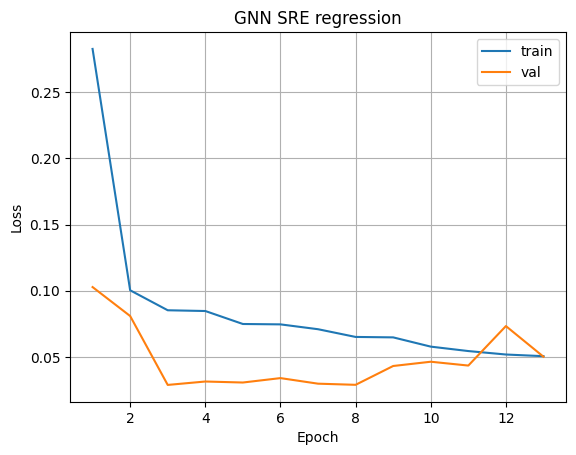

Model checkpoint already exists at %s. Saving to %s instead. ..\models\gnn_huber_random.pt ..\models\gnn_huber_random_v4.pt
Saved model checkpoint to ..\models\gnn_huber_random_v4.pt
Final test loss: 0.032414


In [34]:
model, loss, hist, chkpt = train(
    model_type="gnn",
    epochs = 25,
    lr = 1e-3,
    loss_type = "huber",   # "mse" | "huber"
    batch_size = 64,
    training_mode = "per_family",  # "global" | "per_family"
    family = "random",  # required if training_mode == "per_family"
    target = "sre",
    model_hparams = default_model_hparams,
    train_hparams = default_train_hparams,
    training_data_dir = training_output_dir,
    allow_overwrite = False,
    save_checkpoint = True,
    save_fig = True,
    show_progress = True,
    show_val_progress = False,
    log_every_n_batches = 5,
    heartbeat_secs = 60.0,
    epoch_time_warning_secs = 500.0,
)

print(f"Final test loss: {loss:.6f}")

### NN

In [40]:
default_model_hparams = {
    "hidden_dim": 128,
    "dropout_rate": 0.0,
}

default_train_hparams = {
    "weight_decay": 1e-3,
    "grad_clip": 5.0,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}

Starting training | model_type=regressor | training_mode=per_family | family=random | loss_type=huber
Training configuration done.
Found 30600 data paths.
Data paths collected.
Building loaders and model for model_type=regressor...
Loaders and model built.
Starting training...
Using device: cuda
-------- EPOCH 001 --------
Epoch 1/25:  97%|█████████▋| 333/345 [01:00<00:02,  5.85it/s, loss=0.2942, graphs=21376][Heartbeat] Epoch 1 batch 334/345 | loss 0.294202 | elapsed 60.1s | graphs 21376
Training complete (61.9s) | running validation...                                       
Losses | train 0.288180 | val 0.089044 | lr 1.00e-03 | time train=61.9s val=6.5s total=68.4s
-------- EPOCH 002 --------
Training complete (52.7s) | running validation...                                       
Losses | train 0.057502 | val 0.031731 | lr 1.00e-03 | time train=52.7s val=5.2s total=57.9s
-------- EPOCH 003 --------
Training complete (51.2s) | running validation...                                     

Training complete.


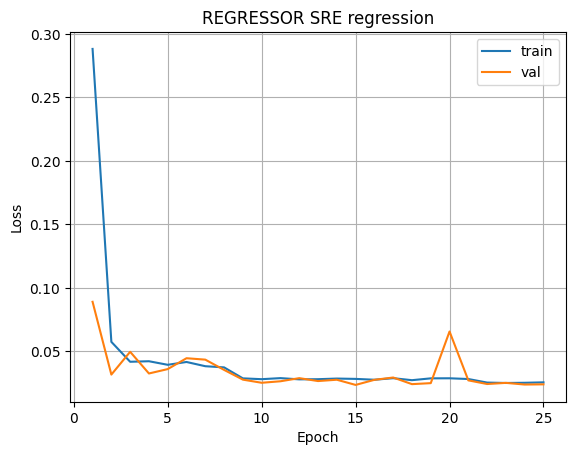

Model checkpoint already exists at %s. Saving to %s instead. ..\models\regressor_huber_random.pt ..\models\regressor_huber_random_v3.pt
Saved model checkpoint to ..\models\regressor_huber_random_v3.pt
Final test loss: 0.027219


In [41]:
model, loss, hist, chkpt = train(
    model_type="regressor",
    epochs = 25,
    lr = 1e-3,
    loss_type = "huber",   # "mse" | "huber"
    batch_size = 64,
    training_mode = "per_family",  # "global" | "per_family"
    family = "random",  # required if training_mode == "per_family"
    target = "sre",
    model_hparams = default_model_hparams,
    train_hparams = default_train_hparams,
    training_data_dir = training_output_dir,
    allow_overwrite = False,
    save_checkpoint = True,
    save_fig = False,
    show_progress = True,
    show_val_progress = False,
    log_every_n_batches = 5,
    heartbeat_secs = 60.0,
    epoch_time_warning_secs = 500.0,
)

print(f"Final test loss: {loss:.6f}")

## Pred

In [4]:
def collect_prediction_paths(dataset_root: str, family: str | None = None) -> list[str]:
    root = Path(dataset_root)
    pred_root = root / "predictions"

    if family is not None:
        paths = sorted((pred_root / family).glob("*.pt"))
    else:
        paths = []
        if pred_root.exists():
            for subdir in sorted(pred_root.iterdir()):
                if subdir.is_dir():
                    paths.extend(sorted(subdir.glob("*.pt")))

    return [str(p.resolve()) for p in paths]


def checkpoint_path(model_kind: str, training_scope: str, family: str | None = None, loss_type: str = "mse") -> Path:
    if model_kind not in {"gnn", "nn", "regressor"}:
        raise ValueError("model_kind must be 'gnn', 'nn', or 'regressor'")
    if training_scope not in {"global", "family"}:
        raise ValueError("training_scope must be 'global' or 'family'")

    if training_scope == "family":
        if family is None:
            raise ValueError("family must be provided when training_scope='family'")
        return Path(f"models/{model_kind}_model_{loss_type}_{family}.pt")

    return Path(f"models/{model_kind}_model_{loss_type}_global.pt")


def load_checkpoint(path: str | Path) -> tuple[dict[str, Any], dict[str, Any], dict[str, Any]]:
    payload = torch.load(path, map_location="cpu", weights_only=False)

    if not isinstance(payload, dict):
        raise RuntimeError("Checkpoint must be a dict.")

    if "model_state_dict" in payload:
        state_dict = payload["model_state_dict"]
        model_config = payload.get("model_config", {}) or {}
        feature_config = payload.get("feature_config", {}) or {}
    else:
        # older raw state_dict format
        state_dict = payload
        model_config = {}
        feature_config = {}

    return state_dict, model_config, feature_config


def build_model(model_kind: str, model_config: dict[str, Any]) -> torch.nn.Module:
    if model_kind == "gnn":
        return GNN(
            node_in_dim=int(model_config["node_in_dim"]),
            global_in_dim=int(model_config["global_in_dim"]),
            gnn_hidden=int(model_config.get("gnn_hidden", 32)),
            gnn_heads=int(model_config.get("gnn_heads", 8)),
            global_hidden=int(model_config.get("global_hidden", 16)),
            reg_hidden=int(model_config.get("reg_hidden", 16)),
            num_layers=int(model_config.get("num_layers", 5)),
            dropout_rate=float(model_config.get("dropout_rate", 0.1)),
        )

    if model_kind == "nn":
        return GlobalMLP(
            in_dim=int(model_config["global_in_dim"]),
            hidden_dim=int(model_config.get("hidden_dim", 128)),
            dropout_rate=model_config.get("dropout_rate", 0.0),
        )

    if model_kind == "regressor":
        return Regressor(
            in_dim=int(model_config["global_in_dim"]),
            hidden_dim=int(model_config.get("hidden_dim", 128)),
            dropout_rate=model_config.get("dropout_rate", 0.0),
        )

    raise ValueError(f"Unsupported model_kind: {model_kind}")


In [8]:
class PredictionGraphWrapper:
    def __init__(
        self,
        dataset,
        target_node_dim: int | None = None,
        target_global_dim: int | None = None,
    ):
        self.dataset = dataset
        self.target_node_dim = target_node_dim
        self.target_global_dim = target_global_dim

    def __len__(self) -> int:
        return len(self.dataset)

    def __getitem__(self, idx: int):
        data = self.dataset[idx].clone()

        if self.target_node_dim is not None:
            cur = int(data.x.shape[1])
            if cur < self.target_node_dim:
                data.x = F.pad(data.x, (0, self.target_node_dim - cur))
            elif cur > self.target_node_dim:
                data.x = data.x[:, : self.target_node_dim]

        if hasattr(data, "global_features"):
            g = data.global_features
            if g.dim() > 1:
                g = g.view(-1)

            if self.target_global_dim is not None:
                cur = int(g.shape[0])
                if cur < self.target_global_dim:
                    g = F.pad(g, (0, self.target_global_dim - cur))
                elif cur > self.target_global_dim:
                    g = g[: self.target_global_dim]

            data.global_features = g

        return data


class PredictionTensorWrapper:
    def __init__(self, dataset, target_global_dim: int | None = None):
        self.dataset = dataset
        self.target_global_dim = target_global_dim

    def __len__(self) -> int:
        return len(self.dataset)

    def __getitem__(self, idx: int):
        data = self.dataset[idx]
        g = data.global_features
        if not torch.is_tensor(g):
            g = torch.as_tensor(g, dtype=torch.float32)
        g = g.flatten().to(torch.float32)

        if self.target_global_dim is not None:
            cur = int(g.shape[0])
            if cur < self.target_global_dim:
                g = F.pad(g, (0, self.target_global_dim - cur))
            elif cur > self.target_global_dim:
                g = g[: self.target_global_dim]

        meta = getattr(data, "meta", {}) or {}
        target = extract_target_value(data)
        return g, meta, target


def build_prediction_dataset(
    pt_paths: list[str],
    *,
    global_feature_variant: str,
    node_feature_backend_variant: str | None,
    fixed_all_gate_keys: list[str] | None,
):
    return QuantumCircuitGraphDataset(
        root="qqe/cache/prediction_cache",
        pt_paths=pt_paths,
        global_feature_variant=global_feature_variant,
        node_feature_backend_variant=node_feature_backend_variant,
        fixed_all_gate_keys=fixed_all_gate_keys,
    )


def build_loader(
    model_kind: str,
    dataset,
    *,
    batch_size: int,
    target_node_dim: int | None,
    target_global_dim: int | None,
):
    if model_kind == "gnn":
        wrapped = PredictionGraphWrapper(
            dataset,
            target_node_dim=target_node_dim,
            target_global_dim=target_global_dim,
        )
        return PyGDataLoader(
            wrapped,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
        )

    if model_kind == "nn" or model_kind == "regressor":
        wrapped = PredictionTensorWrapper(dataset, target_global_dim=target_global_dim)

        def collate_fn(batch):
            xs, metas, targets = zip(*batch)
            return torch.stack(xs, dim=0), list(metas), list(targets)

        return TorchDataLoader(
            wrapped,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
            collate_fn=collate_fn,
        )

    raise ValueError(f"Unsupported model_kind: {model_kind}")

In [7]:
def extract_target_value(sample: Any) -> float | None:
    y = getattr(sample, "y", None)
    if y is None:
        return None

    if torch.is_tensor(y):
        if y.numel() == 0:
            return None
        value = float(y.flatten()[0].item())
    else:
        value = float(y)

    if not np.isfinite(value):
        return None

    return value

@torch.no_grad()
def predict(
    model: torch.nn.Module,
    loader,
    *,
    model_kind: str,
    device: torch.device,
    show_progress: bool = True,
) -> list[dict[str, Any]]:
    model.eval()
    rows: list[dict[str, Any]] = []
    total_batches = len(loader) if hasattr(loader, "__len__") else None

    if model_kind == "gnn":
        for batch in tqdm(
            loader,
            total=total_batches,
            desc="Predicting (gnn)",
            unit="batch",
            disable=not show_progress,
        ):
            samples = batch.to_data_list()
            batch = batch.to(device)
            preds = model(batch).view(-1).cpu().tolist()

            for sample, pred in zip(samples, preds):
                meta = getattr(sample, "meta", {}) or {}
                target = extract_target_value(sample)
                rows.append(
                    {
                        "cid": meta.get("cid"),
                        "family": meta.get("family"),
                        "seed": meta.get("seed"),
                        "n_qubits": meta.get("n_qubits"),
                        "n_layers": meta.get("n_layers"),
                        "target": target,
                        "prediction": float(pred),
                        "error": abs(float(pred - target)) if target is not None else None,
                    },
                )
        return rows

    if model_kind == "nn" or model_kind == "regressor":
        for x, metas, targets in tqdm(
            loader,
            total=total_batches,
            desc="Predicting (nn)",
            unit="batch",
            disable=not show_progress,
        ):
            x = x.to(device)
            preds = model(x).view(-1).cpu().tolist()

            for meta, pred, target in zip(metas, preds, targets):
                rows.append(
                    {
                        "cid": meta.get("cid"),
                        "family": meta.get("family"),
                        "seed": int(meta.get("seed")),
                        "n_qubits": int(meta.get("n_qubits")),
                        "n_layers": int(meta.get("n_layers")),
                        "target": target,
                        "prediction": float(pred),
                        "error": abs(float(pred - target)) if target is not None else None,
                    },
                )
        return rows

    raise ValueError(f"Unsupported model_kind: {model_kind}")


In [9]:
import ast

def to_scalar(x):
    # Already numeric
    if isinstance(x, (int, float)):
        return x

    # torch / numpy scalar
    if hasattr(x, "item"):
        return x.item()

    # Strings
    if isinstance(x, str):
        x = x.strip()

        # Handle tensor(...) by stripping wrapper FIRST
        if x.startswith("tensor(") and x.endswith(")"):
            x = x[len("tensor("):-1].strip()

        try:
            val = ast.literal_eval(x)
        except Exception:
            # fallback: plain float string
            return float(x)

        # If it's a list/tuple like [10]
        if isinstance(val, (list, tuple)):
            if len(val) == 1:
                return float(val[0])
            raise ValueError(f"Unexpected list length: {val}")

        return float(val)

    raise ValueError(f"Unsupported type: {type(x)}")

def save_predictions_csv(rows: list[dict[str, Any]], path: str | Path) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    fieldnames = ["cid", "family", "seed", "n_qubits", "n_layers", "target", "prediction", "error"]
    rows_to_clean = ["seed", "n_qubits", "n_layers"]

    cleaned_rows = []
    for row in rows:
        cleaned = dict(row)
        for key in rows_to_clean:
            if key in cleaned:
                cleaned[key] = to_scalar(cleaned[key])
        cleaned_rows.append(cleaned)

    with path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(cleaned_rows)

    return path


def aggregate_mean_std(
    rows: list[dict[str, Any]],
    *,
    x_key: str,
    fixed_key: str | None = None,
    fixed_value: int | None = None,
) -> list[dict[str, Any]]:
    filtered = rows
    if fixed_key is not None and fixed_value is not None:
        filtered = [r for r in rows if int(r[fixed_key]) == int(fixed_value)]

    groups: dict[int, list[float]] = {}
    for r in filtered:
        x = int(r[x_key])
        groups.setdefault(x, []).append(float(r["prediction"]))

    out = []
    for x in sorted(groups):
        vals = np.asarray(groups[x], dtype=float)
        out.append(
            {
                x_key: x,
                "mean": float(vals.mean()),
                "std": float(vals.std(ddof=0)),
                "n": len(vals),
            },
        )
    return out


# =========================================================
# Plotting
# =========================================================

def plot_fixed_layers_vary_qubits(
    rows: list[dict[str, Any]],
    *,
    n_layers: int,
    output_path: str | Path | None = None,
    split_by_family: bool = True,
):
    filtered = [r for r in rows if int(r["n_layers"]) == int(n_layers)]
    if not filtered:
        print("No predictions found for n_layers=%s", n_layers)
        return

    plt.figure(figsize=(8, 5))

    if split_by_family:
        families = sorted({str(r.get("family", "unknown")) for r in filtered})
        for family in families:
            family_rows = [r for r in filtered if str(r.get("family", "unknown")) == family]

            groups: dict[int, list[float]] = {}
            for r in family_rows:
                q = int(r["n_qubits"])
                groups.setdefault(q, []).append(float(r["prediction"]))

            x = sorted(groups.keys())
            y = [np.mean(groups[q]) for q in x]
            yerr = [np.std(groups[q], ddof=0) for q in x]

            plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="-", capsize=3, label=family)

        plt.legend(title="family")
        plt.title(f"Predicted SRE vs qubits (n_layers={n_layers})")
    else:
        groups: dict[int, list[float]] = {}
        for r in filtered:
            q = int(r["n_qubits"])
            groups.setdefault(q, []).append(float(r["prediction"]))

        x = sorted(groups.keys())
        y = [np.mean(groups[q]) for q in x]
        yerr = [np.std(groups[q], ddof=0) for q in x]

        plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="-", capsize=3)
        plt.title(f"Predicted SRE vs qubits (n_layers={n_layers})")

    plt.xlabel("Number of qubits")
    plt.ylabel("Predicted SRE")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=180)
        plt.close()
    else:
        plt.show()

def plot_fixed_qubits_vary_layers(
    rows: list[dict[str, Any]],
    *,
    n_qubits: int,
    output_path: str | Path | None = None,
    split_by_family: bool = True,
):
    filtered = [r for r in rows if int(r["n_qubits"]) == int(n_qubits)]
    if not filtered:
        print("No predictions found for n_qubits=%s", n_qubits)
        return

    plt.figure(figsize=(8, 5))

    if split_by_family:
        families = sorted({str(r.get("family", "unknown")) for r in filtered})
        for family in families:
            family_rows = [r for r in filtered if str(r.get("family", "unknown")) == family]

            groups: dict[int, list[float]] = {}
            for r in family_rows:
                L = int(r["n_layers"])
                groups.setdefault(L, []).append(float(r["prediction"]))

            x = sorted(groups.keys())
            y = [np.mean(groups[L]) for L in x]
            yerr = [np.std(groups[L], ddof=0) for L in x]

            plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="-", capsize=3, label=family)

        plt.legend(title="family")
        plt.title(f"Predicted SRE vs layers (n_qubits={n_qubits})")
    else:
        groups: dict[int, list[float]] = {}
        for r in filtered:
            L = int(r["n_layers"])
            groups.setdefault(L, []).append(float(r["prediction"]))

        x = sorted(groups.keys())
        y = [np.mean(groups[L]) for L in x]
        yerr = [np.std(groups[L], ddof=0) for L in x]

        plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="-", capsize=3)
        plt.title(f"Predicted SRE vs layers (n_qubits={n_qubits})")

    plt.xlabel("Number of layers")
    plt.ylabel("Predicted SRE")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=180)
        plt.close()
    else:
        plt.show()

In [10]:
def create_predictions(
    model_path: str,
    model_kind: str = "gnn",
    training_scope: str = "family",
    loss_type: str = "mse",
    model_family: str | None = "random",
    data_dir: str = "../outputs/data",
    data_family: str | None = "random",
    batch_size: int = 32,
    global_feature_variant: str = "binned",
    node_feature_backend_variant: str | None = None,
    plot_layers: int = 80,
    plot_qubits: int = 8,
    split_by_family: bool = True,
    show_progress: bool = True,
):
    ckpt_path = checkpoint_path(model_kind, training_scope, model_family, loss_type)
    print("Loading checkpoint: %s", ckpt_path)
    output_csv = f"outputs/figures/predictions/{training_scope}/{model_kind}_predictions_{model_family or 'global'}.csv"

    state_dict, model_config, feature_config = load_checkpoint(model_path)
    print(f"Checkpoint loaded from {model_path}")
    print("Model config:", model_config)
    print("Feature config:", feature_config)
    print("Checkpoint loaded. Building model...")

    model = build_model(model_kind, model_config)
    model.load_state_dict(state_dict, strict=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    pt_paths = collect_prediction_paths(data_dir, data_family)
    if not pt_paths:
        raise RuntimeError("No prediction .pt files found.")

    print("Found %d prediction files", len(pt_paths))

    dataset = build_prediction_dataset(
        pt_paths,
        global_feature_variant=feature_config.get("global_feature_variant", global_feature_variant),
        node_feature_backend_variant=feature_config.get("node_feature_backend_variant", node_feature_backend_variant),
        fixed_all_gate_keys=feature_config.get("all_gate_keys"),
    )

    loader = build_loader(
        model_kind,
        dataset,
        batch_size=batch_size,
        target_node_dim=model_config.get("node_in_dim"),
        target_global_dim=model_config.get("global_in_dim"),
    )

    rows = predict(
        model,
        loader,
        model_kind=model_kind,
        device=device,
        show_progress=show_progress,
    )
    save_predictions_csv(rows, output_csv)

    print("Saved %d predictions to %s", len(rows), output_csv)

    if plot_layers is not None:
        plot_path = f"outputs/figures/predictions/{training_scope}/{model_kind}_pred_layers_{model_family or 'global'}.png"
        plot_fixed_layers_vary_qubits(
            rows,
            n_layers=plot_layers,
            output_path=plot_path,
            split_by_family=split_by_family,
        )
        print("Saved fixed-layer plot to %s", plot_path)

    if plot_qubits is not None:
        plot_path = f"outputs/figures/predictions/{training_scope}/{model_kind}_pred_qubits_{model_family or 'global'}.png"
        plot_fixed_qubits_vary_layers(
            rows,
            n_qubits=plot_qubits,
            output_path=plot_path,
            split_by_family=split_by_family,
        )
        print("Saved fixed-qubit plot to %s", plot_path)
    
    return rows

# Predictions

In [25]:
nn_model_path = "../models/regressor_huber_random_v3.pt"
gnn_model_path = "../models/gnn_huber_random_v4.pt"

In [26]:
model_kind: str = "regressor"  # "gnn" | "nn" | "regressor"
training_scope: str = "family"
loss_type: str = "huber"
model_family: str | None = "random" #"clifford"
dataset_root: str = "data"
dataset_family: str | None = "random"
batch_size: int = 64
global_feature_variant: str = "binned"
node_feature_backend_variant: str | None = None
plot_n_layers: int | None = 80
plot_n_qubits: int | None = 16
split_by_family: bool = True
show_progress: bool = True

In [27]:
preds = create_predictions(
    model_path=nn_model_path,
    model_kind=model_kind,
    training_scope=training_scope,
    loss_type=loss_type,
    model_family=model_family,
    data_dir=dataset_root,
    data_family=dataset_family,
    batch_size=batch_size,
    global_feature_variant=global_feature_variant,
    node_feature_backend_variant=node_feature_backend_variant,
    plot_layers=plot_n_layers,
    plot_qubits=plot_n_qubits,
    split_by_family=split_by_family,
    show_progress=show_progress,
)

Loading checkpoint: %s models\regressor_model_huber_random.pt
Checkpoint loaded from ../models/regressor_huber_random_v3.pt
Model config: {'node_in_dim': 153, 'global_in_dim': 153, 'hidden_dim': 128}
Feature config: {'global_feature_variant': 'binned', 'node_feature_backend_variant': None, 'all_gate_keys': ['CNOT_count', 'rx_bin_0', 'rx_bin_1', 'rx_bin_10', 'rx_bin_11', 'rx_bin_12', 'rx_bin_13', 'rx_bin_14', 'rx_bin_15', 'rx_bin_16', 'rx_bin_17', 'rx_bin_18', 'rx_bin_19', 'rx_bin_2', 'rx_bin_20', 'rx_bin_21', 'rx_bin_22', 'rx_bin_23', 'rx_bin_24', 'rx_bin_25', 'rx_bin_26', 'rx_bin_27', 'rx_bin_28', 'rx_bin_29', 'rx_bin_3', 'rx_bin_30', 'rx_bin_31', 'rx_bin_32', 'rx_bin_33', 'rx_bin_34', 'rx_bin_35', 'rx_bin_36', 'rx_bin_37', 'rx_bin_38', 'rx_bin_39', 'rx_bin_4', 'rx_bin_40', 'rx_bin_41', 'rx_bin_42', 'rx_bin_43', 'rx_bin_44', 'rx_bin_45', 'rx_bin_46', 'rx_bin_47', 'rx_bin_48', 'rx_bin_49', 'rx_bin_5', 'rx_bin_6', 'rx_bin_7', 'rx_bin_8', 'rx_bin_9', 'ry_bin_0', 'ry_bin_1', 'ry_bin_10', 

Predicting (nn): 100%|██████████| 598/598 [01:47<00:00,  5.56batch/s]


Saved %d predictions to %s 38250 outputs/figures/predictions/family/regressor_predictions_random.csv
Saved fixed-layer plot to %s outputs/figures/predictions/family/regressor_pred_layers_random.png
Saved fixed-qubit plot to %s outputs/figures/predictions/family/regressor_pred_qubits_random.png
